### **ALTERNATIVE ANALYSIS: Environment-Only Clustering + Regression**

In [1]:
# Import libraries
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from matplotlib.patches import Patch
 
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score
from sklearn.decomposition import PCA
 
from scipy import stats
from scipy.cluster.hierarchy import linkage, fcluster
from itertools import permutations
 
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
 
import scikit_posthocs as sp
 
np.random.seed(42)
 
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'figure.facecolor': 'white'
})

In [2]:
# Load the data
gdf = gpd.read_file('GLA_Master.shp')

# Clean columns (consistent with original notebook)
gdf['IncRate_2020'] = gdf['IncRate'].str.replace('%', '').astype(float)
gdf['IncRate_2016'] = gdf['IncRate_1'] * 100
gdf['VDL_2020']     = gdf['VDL_Ratio2']
gdf['VDL_2016']     = gdf['VDL_Ratio1']
gdf['NoGreen']      = 1 - gdf['PAN_GreenR']
gdf['Inc_Change']   = gdf['IncRate_2020'] - gdf['IncRate_2016']
 
# clustering uses ONLY the 3 environmental variables
env_cols   = ['NO2_2020', 'VDL_2020', 'NoGreen']
env_labels = ['NO₂', 'VDL', 'Lack of green space']
 
# Income and health are kept separate
income_col = 'IncRate_2020'
health_col = 'HlthCIF'
 
# NaN check
print('NaN check:')
for col in env_cols + [income_col, health_col]:
    n_miss = gdf[col].isna().sum()
    if n_miss > 0:
        med = gdf[col].median()
        print(f'  WARNING: {col} has {n_miss} NaN(s) → filling with median ({med:.2f})')
        gdf[col] = gdf[col].fillna(med)
    else:
        print(f'  OK: {col}')
 
X_raw = gdf[env_cols].values
print()
print(f'Clustering on {len(env_cols)} ENVIRONMENTAL variables, {X_raw.shape[0]} zones')
print(f'Income variable (regression only): {income_col}')
print(f'Health outcome (regression only):  {health_col}')

NaN check:
  OK: NO2_2020
  OK: VDL_2020
  OK: NoGreen
  OK: IncRate_2020
  OK: HlthCIF

Clustering on 3 ENVIRONMENTAL variables, 746 zones
Income variable (regression only): IncRate_2020
Health outcome (regression only):  HlthCIF



CORRELATION MATRIX OF ENVIRONMENTAL VARIABLES


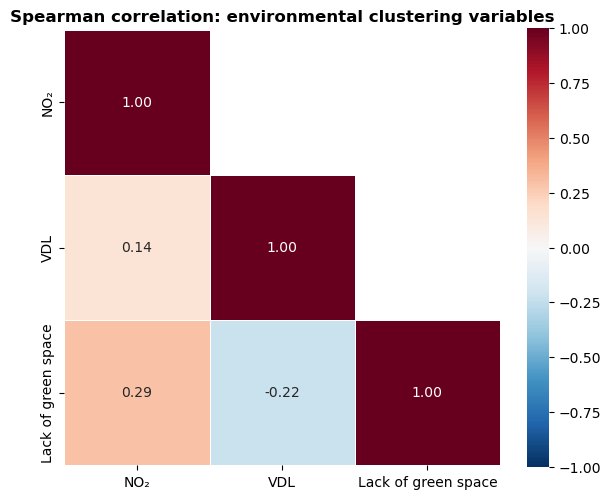


Correlations with Income and Health:
Variable                  r(Income)    r(Health)
--------------------------------------------------
NO₂                          -0.115       -0.130
VDL                          +0.359       +0.374
Lack of green space          -0.188       -0.200


In [3]:
# 2. CORRELATION CHECK
 
print()
print('=' * 60)
print('CORRELATION MATRIX OF ENVIRONMENTAL VARIABLES')
print('=' * 60)
 
corr_env = gdf[env_cols].corr(method='spearman')
 
fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr_env, dtype=bool), k=1)
sns.heatmap(corr_env, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, mask=mask,
            xticklabels=env_labels, yticklabels=env_labels, ax=ax,
            square=True, linewidths=0.5)
ax.set_title('Spearman correlation: environmental clustering variables')
plt.tight_layout()
plt.savefig('fig_env_correlation.png', dpi=200, bbox_inches='tight')
plt.show()
 
# Correlation of each env variable with income and health
print()
print('Correlations with Income and Health:')
print(f'{"Variable":<22} {"r(Income)":>12} {"r(Health)":>12}')
print('-' * 50)
for col, lab in zip(env_cols, env_labels):
    r_inc, _ = stats.spearmanr(gdf[col], gdf[income_col])
    r_hlt, _ = stats.spearmanr(gdf[col], gdf[health_col])
    print(f'{lab:<22} {r_inc:>+12.3f} {r_hlt:>+12.3f}')

In [4]:
# 3. Z-SCORE STANDARDISATION
 
scaler = StandardScaler()
X_z = scaler.fit_transform(X_raw)
 
print()
print('Z-score standardised ranges (environmental variables):')
for i, col in enumerate(env_cols):
    v = X_z[:, i]
    print(f'  {col}: {v.min():.3f} to {v.max():.3f}')


Z-score standardised ranges (environmental variables):
  NO2_2020: -1.882 to 3.672
  VDL_2020: -0.695 to 3.313
  NoGreen: -4.752 to 1.835


c:\Users\Lenovo\anaconda3\envs\spatial-regression\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\Lenovo\anaconda3\envs\spatial-regression\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Lenovo\anaconda3\envs\spatial-regression\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to 

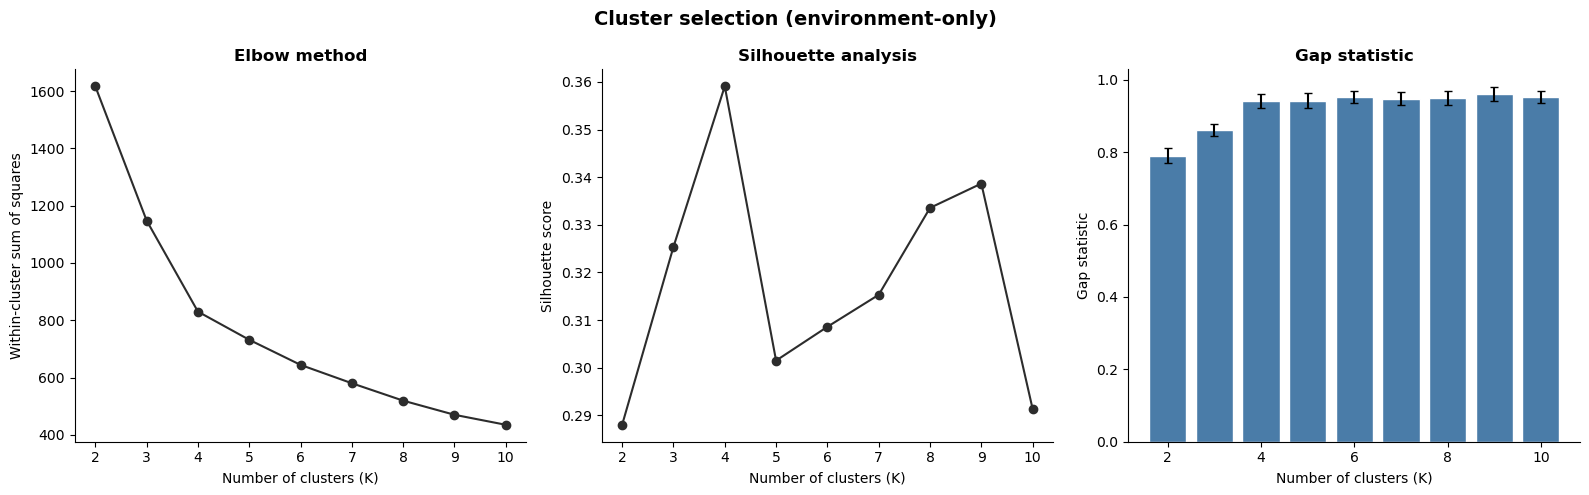


K           WCSS   Silhouette        Gap
----------------------------------------
2         1617.2       0.2880     0.7903
3         1148.3       0.3254     0.8624
4          830.2       0.3591     0.9409
5          731.8       0.3015     0.9420
6          644.2       0.3086     0.9523
7          580.1       0.3153     0.9482
8          519.3       0.3336     0.9491
9          469.9       0.3387     0.9610
10         435.0       0.2913     0.9524

Gap statistic optimal K = 4
Silhouette peak at K = 4


In [5]:
# 4. OPTIMAL K SELECTION
 
K_range = range(2, 11)
 
# Elbow
wcss = []
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=50, random_state=42)
    km.fit(X_z)
    wcss.append(km.inertia_)
 
# Silhouette
sil_scores = []
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=50, random_state=42)
    labels = km.fit_predict(X_z)
    sil_scores.append(silhouette_score(X_z, labels))
 
# Gap statistic
def gap_statistic(X, K_range, n_refs=50):
    gaps, s_k = [], []
    for k in K_range:
        km = KMeans(n_clusters=k, init='k-means++', n_init=50, random_state=42)
        km.fit(X)
        obs = np.log(km.inertia_)
        refs = []
        for _ in range(n_refs):
            X_ref = np.random.uniform(X.min(axis=0), X.max(axis=0), size=X.shape)
            km_r = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
            km_r.fit(X_ref)
            refs.append(np.log(km_r.inertia_))
        gaps.append(np.mean(refs) - obs)
        s_k.append(np.std(refs) * np.sqrt(1 + 1/n_refs))
    return gaps, s_k
 
gaps, s_k = gap_statistic(X_z, K_range)
 
# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
 
axes[0].plot(list(K_range), wcss, 'o-', color='#2C2C2C', markersize=6)
axes[0].set_xlabel('Number of clusters (K)')
axes[0].set_ylabel('Within-cluster sum of squares')
axes[0].set_title('Elbow method')
axes[0].spines[['top', 'right']].set_visible(False)
 
axes[1].plot(list(K_range), sil_scores, 'o-', color='#2C2C2C', markersize=6)
axes[1].set_xlabel('Number of clusters (K)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette analysis')
axes[1].spines[['top', 'right']].set_visible(False)
 
axes[2].bar(list(K_range), gaps, yerr=s_k, color='#4A7CA8', edgecolor='white', capsize=3)
axes[2].set_xlabel('Number of clusters (K)')
axes[2].set_ylabel('Gap statistic')
axes[2].set_title('Gap statistic')
axes[2].spines[['top', 'right']].set_visible(False)
 
plt.suptitle('Cluster selection (environment-only)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_env_cluster_selection.png', dpi=200, bbox_inches='tight')
plt.show()
 
# Summary
print()
print(f'{"K":<5} {"WCSS":>10} {"Silhouette":>12} {"Gap":>10}')
print('-' * 40)
for i, k in enumerate(K_range):
    print(f'{k:<5} {wcss[i]:>10.1f} {sil_scores[i]:>12.4f} {gaps[i]:>10.4f}')
 
# Tibshirani rule
optimal_k_gap = None
for i in range(len(gaps) - 1):
    if gaps[i] >= gaps[i+1] - s_k[i+1]:
        optimal_k_gap = list(K_range)[i]
        print(f'\nGap statistic optimal K = {optimal_k_gap}')
        break
 
optimal_k_sil = list(K_range)[np.argmax(sil_scores)]
print(f'Silhouette peak at K = {optimal_k_sil}')

In [6]:
# KMeans clustering with optimal K
K = 4
 
# K-MEANS CLUSTERING (ENVIRONMENT ONLY)
 
km_final = KMeans(n_clusters=K, init='k-means++', n_init=50, random_state=42)
gdf['EnvCluster'] = km_final.fit_predict(X_z)
 
sil = silhouette_score(X_z, gdf['EnvCluster'])
print()
print(f'K-means clustering (K={K}, environment-only)')
print(f'Silhouette score: {sil:.4f}')
print()
print('Cluster sizes:')
print(gdf['EnvCluster'].value_counts().sort_index())


K-means clustering (K=4, environment-only)
Silhouette score: 0.3591

Cluster sizes:
EnvCluster
0    125
1    177
2    120
3    324
Name: count, dtype: int64


c:\Users\Lenovo\anaconda3\envs\spatial-regression\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [7]:
# 6. CLUSTER PROFILING & NAMING
 
# Z-score profiles
profile_z = pd.DataFrame(X_z, columns=env_labels)
profile_z['EnvCluster'] = gdf['EnvCluster'].values
means_z = profile_z.groupby('EnvCluster').mean()
 
# Also compute mean income and health per cluster (NOT used for naming,just for descriptive context)
for_context = gdf.groupby('EnvCluster').agg(
    Income_mean = (income_col, 'mean'),
    Health_mean = (health_col, 'mean'),
    n = (health_col, 'count')
).round(2)
 
print()
print('=' * 70)
print('ENVIRONMENT-ONLY CLUSTER PROFILES (z-scores)')
print('=' * 70)
print()
print(means_z.round(2).to_string())
print()
print('Context (NOT used for naming):')
print(for_context.to_string())


ENVIRONMENT-ONLY CLUSTER PROFILES (z-scores)

             NO₂   VDL  Lack of green space
EnvCluster                                 
0           1.71 -0.11                 0.58
1          -0.62 -0.27                -1.28
2          -0.02  1.88                -0.16
3          -0.31 -0.50                 0.53

Context (NOT used for naming):
            Income_mean  Health_mean    n
EnvCluster                               
0                 16.11       127.96  125
1                 21.61       164.63  177
2                 28.93       202.67  120
3                 16.83       135.45  324


In [8]:
env_cluster_names = {
    0: 'High-pollution core',
    1: 'Green periphery',
    2: 'Industrial dereliction',
    3: 'Moderate urban',
}
# Only keep entries up to K
env_cluster_names = {k: v for k, v in env_cluster_names.items() if k < K}
 
gdf['EnvType'] = gdf['EnvCluster'].map(env_cluster_names)
 
# Colour scheme
ENV_COLORS = {
    'High-pollution core': '#d73027',
    'Green periphery': '#fc8d59',
    'Industrial dereliction': '#91bfdb',
    'Moderate urban': '#4575b4',
}
 
# Order by mean disadvantage (average z-score across 3 env variables)
means_z['Disadvantage'] = means_z.mean(axis=1)
env_type_order = [env_cluster_names[c] for c in
                  means_z['Disadvantage'].sort_values(ascending=False).index
                  if c in env_cluster_names]
 
print()
print('Cluster naming (adjust as needed):')
for cid in means_z['Disadvantage'].sort_values(ascending=False).index:
    if cid in env_cluster_names:
        name = env_cluster_names[cid]
        n = (gdf['EnvCluster'] == cid).sum()
        score = means_z.loc[cid, 'Disadvantage']
        print(f'  Cluster {cid} → {name}  (n={n}, env disadvantage={score:+.3f})')


Cluster naming (adjust as needed):
  Cluster 0 → High-pollution core  (n=125, env disadvantage=+0.724)
  Cluster 2 → Industrial dereliction  (n=120, env disadvantage=+0.567)
  Cluster 3 → Moderate urban  (n=324, env disadvantage=-0.094)
  Cluster 1 → Green periphery  (n=177, env disadvantage=-0.723)


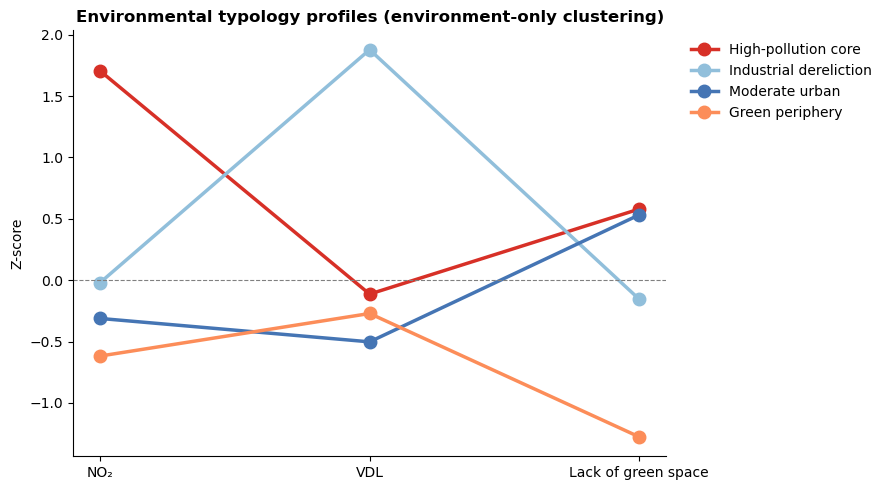

In [9]:
# VISUALISATION: PROFILES
 
# Parallel coordinates
fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(env_labels))
for tname in env_type_order:
    cid = [c for c, n in env_cluster_names.items() if n == tname][0]
    vals = means_z.drop(columns='Disadvantage').loc[cid].values
    ax.plot(x, vals, 'o-', linewidth=2.5, label=tname,
            color=ENV_COLORS.get(tname, '#888'), markersize=9)
 
ax.set_xticks(x)
ax.set_xticklabels(env_labels)
ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
ax.set_ylabel('Z-score')
ax.set_title('Environmental typology profiles (environment-only clustering)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig_env_profiles.png', dpi=200, bbox_inches='tight')
plt.show()

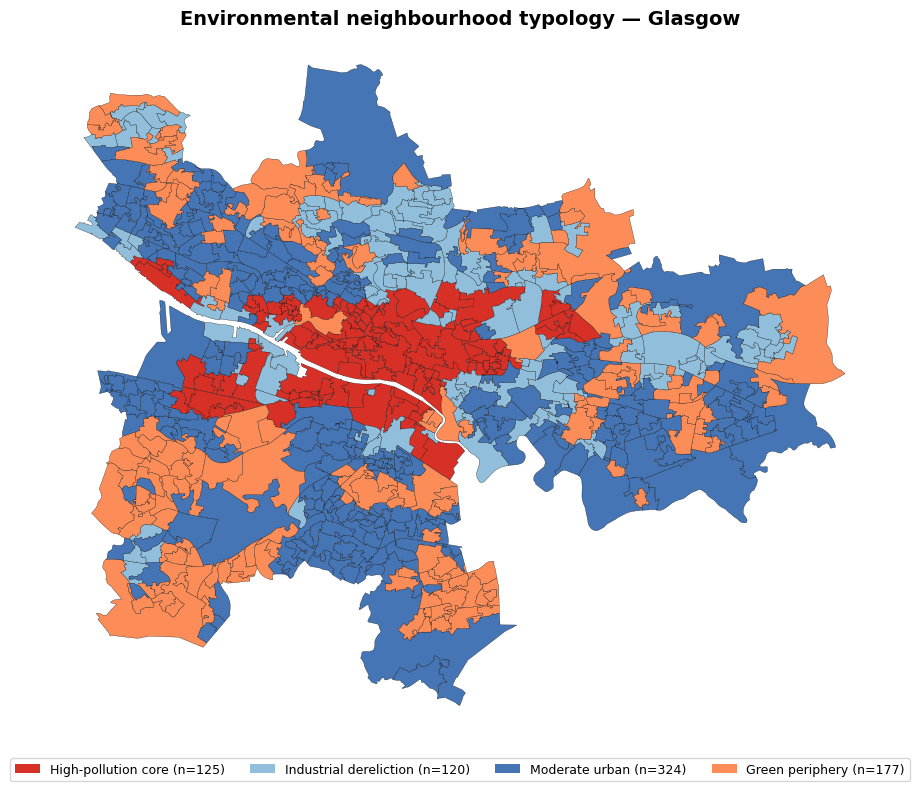

In [10]:
# 8. VISUALISATION: SPATIAL MAP
 
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
 
for tname in env_type_order:
    subset = gdf[gdf['EnvType'] == tname]
    if len(subset) > 0:
        subset.plot(ax=ax, color=ENV_COLORS.get(tname, '#ccc'),
                    edgecolor='black', linewidth=0.2)
 
ax.set_title('Environmental neighbourhood typology — Glasgow', fontsize=14,
             fontweight='bold')
ax.axis('off')
handles = [Patch(facecolor=ENV_COLORS.get(t, '#ccc'),
                 label=t + f" (n={(gdf['EnvType']==t).sum()})")
           for t in env_type_order]
ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.02),
          ncol=K, frameon=True, fontsize=9)
plt.tight_layout()
plt.savefig('fig_env_spatial_map.png', dpi=200, bbox_inches='tight')
plt.show()

Env Type A (125 districts): extremely high NO ₂ (z=+1.71), with few green spaces. This is the area along the highway in the city center, where the air quality is the worst but the residents' income is not low (16.1%), and their health is actually the best (128.0).

Env Type C (120 districts): VDL is extremely high (z=+1.88), with abandoned industrial land everywhere. This is the Clyde River Corridor and the East End, Glasgow's industrial heritage belt. Here, the income is the lowest (28.9%) and the health is also the worst (202.7).

Env Type D (324 zones): All three environmental indicators are close to average, and there are no particularly prominent environmental issues. This is the largest type, representing ordinary urban environments. Income 16.8%, health 135.4.

Env Type B (177 districts): Excellent green space (z=-1.28), good air quality, and minimal abandoned land. This is a green suburb on the outskirts of the city. But its income (21.6%) is actually higher than Type A and Type D, and its health (164.6) is also worse than them.


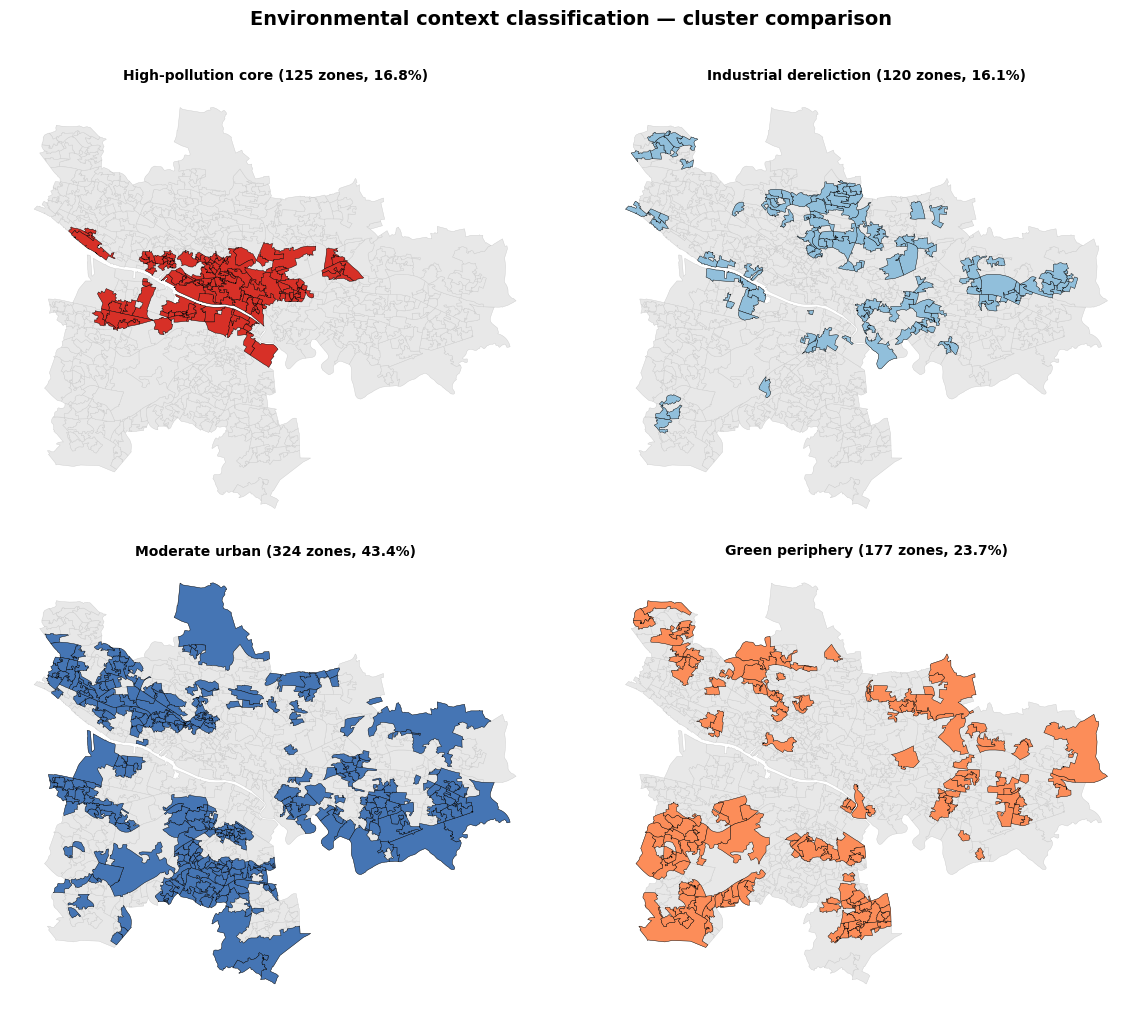

In [11]:
# Cluster comparison grid (environment-only typology)

n_types = len(env_type_order)
nrows = (n_types + 1) // 2
fig, axes = plt.subplots(nrows, 2, figsize=(12, 5 * nrows))
axes = axes.flatten()

for idx, tname in enumerate(env_type_order):
    ax = axes[idx]
    gdf.plot(ax=ax, color='#E8E8E8', edgecolor='#CCCCCC', linewidth=0.3)
    subset = gdf[gdf['EnvType'] == tname]
    if len(subset) > 0:
        subset.plot(ax=ax, color=ENV_COLORS.get(tname, '#ccc'),
                    edgecolor='black', linewidth=0.3)
    n = len(subset)
    pct = n / len(gdf) * 100
    ax.set_title(f'{tname} ({n} zones, {pct:.1f}%)', fontsize=10)
    ax.axis('off')

for idx in range(len(env_type_order), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Environmental context classification — cluster comparison',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_env_cluster_grid.png', dpi=200, bbox_inches='tight')
plt.show()


INCOME AND HEALTH BY ENVIRONMENTAL TYPE

Type                     N    Income%    HlthCIF
--------------------------------------------------
High-pollution core    125      16.11      128.0
Industrial dereliction   120      28.93      202.7
Moderate urban         324      16.83      135.4
Green periphery        177      21.61      164.6


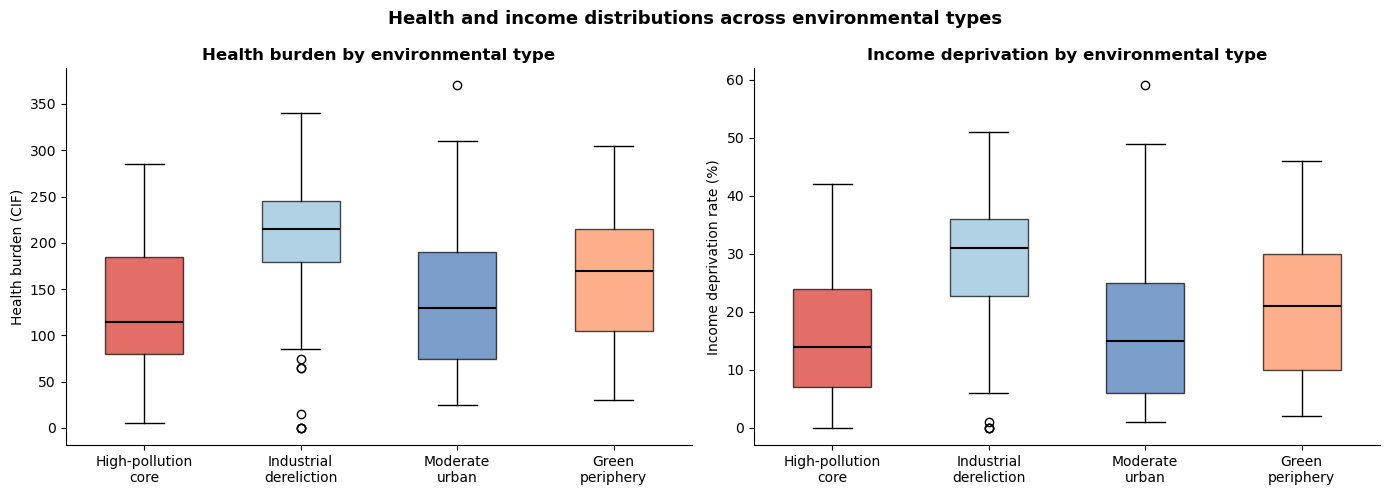

In [12]:
# 9. DESCRIPTIVE: INCOME & HEALTH BY ENVIRONMENTAL TYPE
 
print()
print('=' * 70)
print('INCOME AND HEALTH BY ENVIRONMENTAL TYPE')
print('=' * 70)
print()
print(f'{"Type":<20} {"N":>5} {"Income%":>10} {"HlthCIF":>10}')
print('-' * 50)
for t in env_type_order:
    s = gdf[gdf['EnvType'] == t]
    print(f'{t:<20} {len(s):>5} {s[income_col].mean():>10.2f} '
          f'{s[health_col].mean():>10.1f}')
 
# Boxplot: health by env type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Health
groups_h = [gdf[gdf['EnvType'] == t][health_col].values for t in env_type_order]
bp1 = axes[0].boxplot(groups_h,
                       tick_labels=[t.replace(' ', '\n') for t in env_type_order],
                       patch_artist=True, widths=0.5,
                       medianprops=dict(color='black', linewidth=1.5))
for i, tname in enumerate(env_type_order):
    bp1['boxes'][i].set_facecolor(ENV_COLORS.get(tname, '#ccc'))
    bp1['boxes'][i].set_alpha(0.7)
axes[0].set_ylabel('Health burden (CIF)')
axes[0].set_title('Health burden by environmental type')
axes[0].spines[['top', 'right']].set_visible(False)
 
# Income
groups_i = [gdf[gdf['EnvType'] == t][income_col].values for t in env_type_order]
bp2 = axes[1].boxplot(groups_i,
                       tick_labels=[t.replace(' ', '\n') for t in env_type_order],
                       patch_artist=True, widths=0.5,
                       medianprops=dict(color='black', linewidth=1.5))
for i, tname in enumerate(env_type_order):
    bp2['boxes'][i].set_facecolor(ENV_COLORS.get(tname, '#ccc'))
    bp2['boxes'][i].set_alpha(0.7)
axes[1].set_ylabel('Income deprivation rate (%)')
axes[1].set_title('Income deprivation by environmental type')
axes[1].spines[['top', 'right']].set_visible(False)
 
plt.suptitle('Health and income distributions across environmental types',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_env_health_income_boxplot.png', dpi=200, bbox_inches='tight')
plt.show()

In [13]:
# 10. REGRESSION ANALYSIS
# Core question: After controlling for income deprivation, do environmental
#   neighbourhood types still have a statistically significant association
#   with health outcomes?
 
print()
print('=' * 80)
print('REGRESSION ANALYSIS')
print('=' * 80)
 
# Set the reference category to the env type with the lowest disadvantage
ref_type = env_type_order[-1]  # last in descending order = least disadvantaged
print(f'\nReference environmental type: {ref_type}')
 
# Model 1: Income only
model1 = smf.ols(f'{health_col} ~ {income_col}', data=gdf).fit()
 
# Model 2: Environment type only
gdf['EnvType_cat'] = pd.Categorical(gdf['EnvType'], categories=env_type_order)
model2 = smf.ols(f'{health_col} ~ C(EnvType_cat, Treatment(reference="{ref_type}"))',
                 data=gdf).fit()
 
# Model 3: Income + Environment type (the key model)
model3 = smf.ols(
    f'{health_col} ~ {income_col} + C(EnvType_cat, Treatment(reference="{ref_type}"))',
    data=gdf
).fit()
 
# Print results
print()
print('─' * 80)
print('MODEL 1: HlthCIF ~ Income deprivation only')
print('─' * 80)
print(model1.summary2().tables[1].to_string())
print(f'\n  R² = {model1.rsquared:.4f},  Adj-R² = {model1.rsquared_adj:.4f}')
print(f'  AIC = {model1.aic:.1f},  BIC = {model1.bic:.1f}')
 
print()
print('─' * 80)
print('MODEL 2: HlthCIF ~ Environmental type only')
print('─' * 80)
print(model2.summary2().tables[1].to_string())
print(f'\n  R² = {model2.rsquared:.4f},  Adj-R² = {model2.rsquared_adj:.4f}')
print(f'  AIC = {model2.aic:.1f},  BIC = {model2.bic:.1f}')
 
print()
print('─' * 80)
print('MODEL 3: HlthCIF ~ Income deprivation + Environmental type')
print('─' * 80)
print(model3.summary2().tables[1].to_string())
print(f'\n  R² = {model3.rsquared:.4f},  Adj-R² = {model3.rsquared_adj:.4f}')
print(f'  AIC = {model3.aic:.1f},  BIC = {model3.bic:.1f}')
 
# R² comparison
print()
print('=' * 80)
print('MODEL COMPARISON')
print('=' * 80)
print()
print(f'  {"Model":<45} {"R²":>8} {"Adj-R²":>8} {"AIC":>10}')
print(f'  {"-"*75}')
print(f'  {"M1: Income only":<45} {model1.rsquared:>8.4f} '
      f'{model1.rsquared_adj:>8.4f} {model1.aic:>10.1f}')
print(f'  {"M2: Env type only":<45} {model2.rsquared:>8.4f} '
      f'{model2.rsquared_adj:>8.4f} {model2.aic:>10.1f}')
print(f'  {"M3: Income + Env type":<45} {model3.rsquared:>8.4f} '
      f'{model3.rsquared_adj:>8.4f} {model3.aic:>10.1f}')
 
delta_r2 = model3.rsquared - model1.rsquared
print(f'\n  ΔR² (M3 vs M1) = {delta_r2:.4f}')
print(f'  → Adding environmental types to income explains an additional '
      f'{delta_r2*100:.2f}% of variance in health burden.')
 
# F-test: does Model 3 significantly improve over Model 1?
# (Nested model comparison)
f_stat = ((model1.ssr - model3.ssr) / (model1.df_resid - model3.df_resid)) / \
         (model3.ssr / model3.df_resid)
df1 = model1.df_resid - model3.df_resid
df2 = model3.df_resid
f_pvalue = 1 - stats.f.cdf(f_stat, df1, df2)
 
print()
print(f'  F-test (M3 vs M1): F({df1},{df2}) = {f_stat:.3f}, p = {f_pvalue:.4e}')
if f_pvalue < 0.05:
    print(f'  → Environmental types provide a STATISTICALLY SIGNIFICANT '
          f'improvement over income alone.')
    if delta_r2 < 0.02:
        print(f'  → However, the additional explained variance is very small '
              f'({delta_r2*100:.2f}%), suggesting the practical significance '
              f'is limited.')
else:
    print(f'  → Environmental types do NOT significantly improve the model '
          f'beyond income alone.')


REGRESSION ANALYSIS

Reference environmental type: Green periphery

────────────────────────────────────────────────────────────────────────────────
MODEL 1: HlthCIF ~ Income deprivation only
────────────────────────────────────────────────────────────────────────────────
                  Coef.  Std.Err.          t          P>|t|     [0.025     0.975]
Intercept     39.756195  1.513850  26.261656  4.464756e-108  36.784270  42.728121
IncRate_2020   5.667584  0.065097  87.064096   0.000000e+00   5.539789   5.795379

  R² = 0.9106,  Adj-R² = 0.9105
  AIC = 6711.0,  BIC = 6720.3

────────────────────────────────────────────────────────────────────────────────
MODEL 2: HlthCIF ~ Environmental type only
────────────────────────────────────────────────────────────────────────────────
                                                                                       Coef.  Std.Err.          t          P>|t|      [0.025      0.975]
Intercept                                                 


REGRESSION DIAGNOSTICS (Model 3)

  Breusch-Pagan test: stat=18.61, p=9.3751e-04
  → Heteroscedasticity detected. Consider robust standard errors.

  Model 3 with HC3 robust standard errors:
                                                                                      Coef.  Std.Err.          z         P>|z|     [0.025     0.975]
Intercept                                                                         42.324711  2.141963  19.759776  6.609710e-87  38.126541  46.522882
C(EnvType_cat, Treatment(reference="Green periphery"))[T.High-pollution core]     -5.554529  2.553193  -2.175523  2.959096e-02 -10.558695  -0.550363
C(EnvType_cat, Treatment(reference="Green periphery"))[T.Industrial dereliction]  -3.413344  2.841691  -1.201167  2.296866e-01  -8.982957   2.156268
C(EnvType_cat, Treatment(reference="Green periphery"))[T.Moderate urban]          -2.149561  2.032280  -1.057709  2.901881e-01  -6.132757   1.833635
IncRate_2020                                                   

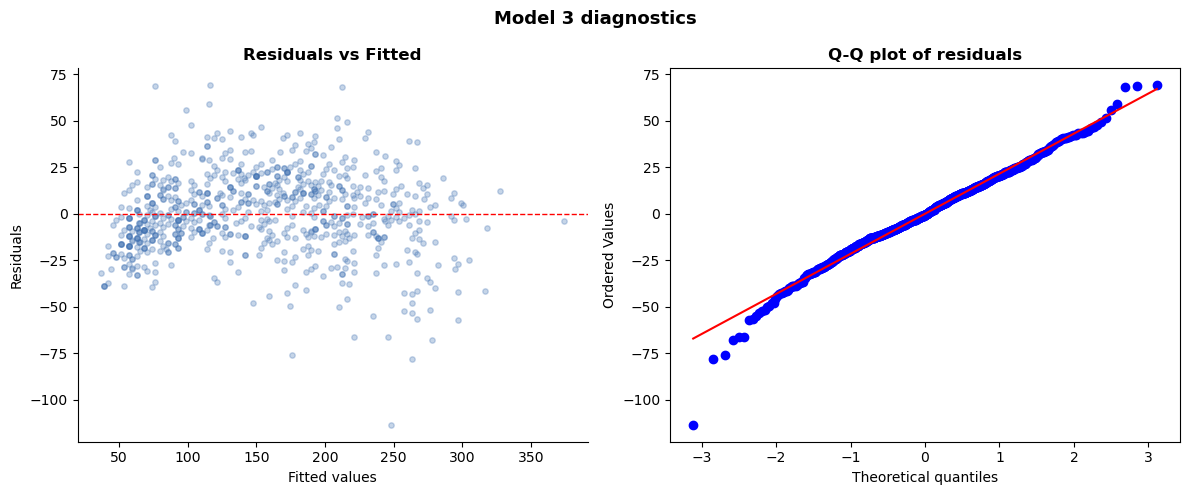

In [14]:
#11. DIAGNOSTIC CHECKS
 
print()
print('=' * 80)
print('REGRESSION DIAGNOSTICS (Model 3)')
print('=' * 80)
 
# Breusch-Pagan heteroscedasticity test
bp_stat, bp_pval, _, _ = het_breuschpagan(model3.resid, model3.model.exog)
print(f'\n  Breusch-Pagan test: stat={bp_stat:.2f}, p={bp_pval:.4e}')
if bp_pval < 0.05:
    print('  → Heteroscedasticity detected. Consider robust standard errors.')
    # Refit with robust SEs
    model3_robust = smf.ols(
        f'{health_col} ~ {income_col} + C(EnvType_cat, Treatment(reference="{ref_type}"))',
        data=gdf
    ).fit(cov_type='HC3')
    print()
    print('  Model 3 with HC3 robust standard errors:')
    print(model3_robust.summary2().tables[1].to_string())
 
# VIF for income
X_vif = gdf[[income_col]].copy()
for t in env_type_order:
    if t != ref_type:
        X_vif[f'EnvType_{t}'] = (gdf['EnvType'] == t).astype(int)
X_vif = sm.add_constant(X_vif)
print()
print('  Variance Inflation Factors:')
for i, col in enumerate(X_vif.columns):
    vif = variance_inflation_factor(X_vif.values, i)
    print(f'    {col:<30} VIF = {vif:.2f}')
 
# Residual plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
axes[0].scatter(model3.fittedvalues, model3.resid, alpha=0.3, s=15, color='#4575b4')
axes[0].axhline(0, color='red', linewidth=1, linestyle='--')
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')
axes[0].spines[['top', 'right']].set_visible(False)
 
stats.probplot(model3.resid, plot=axes[1])
axes[1].set_title('Q-Q plot of residuals')
 
plt.suptitle('Model 3 diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_regression_diagnostics.png', dpi=200, bbox_inches='tight')
plt.show()

In [15]:
# 12. ROBUSTNESS CHECKS FOR CLUSTERING
 
print()
print('=' * 80)
print('ROBUSTNESS CHECKS (Environment-only clustering)')
print('=' * 80)
 
# ARI stability
aris = []
reference_labels = None
for seed in range(50):
    km = KMeans(n_clusters=K, init='k-means++', n_init=50, random_state=seed)
    labels = km.fit_predict(X_z)
    if reference_labels is None:
        reference_labels = labels
    else:
        aris.append(adjusted_rand_score(reference_labels, labels))
 
print(f'\n  ARI stability (50 seeds): mean={np.mean(aris):.4f}, '
      f'std={np.std(aris):.4f}, min={np.min(aris):.4f}')
 
# Min-Max sensitivity
scaler_mm = MinMaxScaler()
X_mm = scaler_mm.fit_transform(X_raw)
km_mm = KMeans(n_clusters=K, init='k-means++', n_init=50, random_state=42)
labels_mm = km_mm.fit_predict(X_mm)
 
best_match_mm, best_perm_mm = 0, None
for perm in permutations(range(K)):
    remapped = np.array([perm[l] for l in labels_mm])
    match = (remapped == gdf['EnvCluster'].values).sum()
    if match > best_match_mm:
        best_match_mm = match
        best_perm_mm = perm
mm_consistency = best_match_mm / len(gdf) * 100
 
print(f'  Min-Max agreement: {best_match_mm}/{len(gdf)} ({mm_consistency:.1f}%)')
 
# Ward comparison
Z_linkage = linkage(X_z, method='ward')
ward_labels = fcluster(Z_linkage, t=K, criterion='maxclust') - 1
 
best_match_w, best_perm_w = 0, None
for perm in permutations(range(K)):
    remapped = np.array([perm[l] for l in ward_labels])
    match = (remapped == gdf['EnvCluster'].values).sum()
    if match > best_match_w:
        best_match_w = match
        best_perm_w = perm
w_consistency = best_match_w / len(gdf) * 100
 
print(f'  Ward agreement:    {best_match_w}/{len(gdf)} ({w_consistency:.1f}%)')
 
# Silhouette
km_sil = silhouette_score(X_z, gdf['EnvCluster'])
ward_sil = silhouette_score(X_z, ward_labels)
print(f'  K-means silhouette: {km_sil:.4f}')
print(f'  Ward silhouette:    {ward_sil:.4f}')


ROBUSTNESS CHECKS (Environment-only clustering)


c:\Users\Lenovo\anaconda3\envs\spatial-regression\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Lenovo\anaconda3\envs\spatial-regression\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Lenovo\anaconda3\envs\spatial-regression\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Lenovo\anaconda3\envs\spatial-regression\Lib\site-pa


  ARI stability (50 seeds): mean=0.9965, std=0.0062, min=0.9847
  Min-Max agreement: 711/746 (95.3%)
  Ward agreement:    574/746 (76.9%)


c:\Users\Lenovo\anaconda3\envs\spatial-regression\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


  K-means silhouette: 0.3591
  Ward silhouette:    0.2992


In [16]:
# 13. SUMMARY TABLE
 
print()
print('=' * 80)
print('FINAL SUMMARY: ENVIRONMENT-ONLY TYPOLOGY + REGRESSION')
print('=' * 80)
 
print()
print(f'  {"Type":<20} {"N":>5} ', end='')
for lab in env_labels:
    print(f'{lab[:10]:>10} ', end='')
print(f'{"Income%":>10} {"HlthCIF":>10}')
print(f'  {"-"*80}')
for tname in env_type_order:
    subset = gdf[gdf['EnvType'] == tname]
    row = f'  {tname:<20} {len(subset):>5} '
    for col in env_cols:
        row += f'{subset[col].mean():>10.2f} '
    row += f'{subset[income_col].mean():>10.2f} '
    row += f'{subset[health_col].mean():>10.1f}'
    print(row)
 
print()
print(f'  Clustering: K-means (K={K}), environment variables only')
print(f'  Silhouette score: {km_sil:.4f}')
print(f'  ARI stability:    {np.mean(aris):.4f}')
print()
print(f'  Income-only R²:           {model1.rsquared:.4f}')
print(f'  Income + Env-type R²:     {model3.rsquared:.4f}')
print(f'  ΔR²:                      {delta_r2:.4f} ({delta_r2*100:.2f}%)')
print(f'  F-test p-value:           {f_pvalue:.4e}')
print()
 
if f_pvalue < 0.05 and delta_r2 < 0.02:
    print('  INTERPRETATION: Environmental types are statistically significant')
    print('  but explain very little additional variance beyond income.')
    print('  Income deprivation dominates the prediction of health burden.')
elif f_pvalue >= 0.05:
    print('  INTERPRETATION: Environmental types do not significantly improve')
    print('  health prediction beyond income. Income deprivation is the')
    print('  dominant correlate of neighbourhood health burden.')
else:
    print('  INTERPRETATION: Environmental types explain meaningful additional')
    print('  variance beyond income, suggesting an independent association')
    print('  between environmental context and health outcomes.')
 
print()
print('  CAUTION: These are cross-sectional associations. The analysis')
print('  cannot distinguish sorting/selection effects from contextual/')
print('  environmental effects. See discussion of composition vs context.')


FINAL SUMMARY: ENVIRONMENT-ONLY TYPOLOGY + REGRESSION

  Type                     N        NO₂        VDL Lack of gr    Income%    HlthCIF
  --------------------------------------------------------------------------------
  High-pollution core    125      19.82       0.14       0.86      16.11      128.0
  Industrial dereliction   120      13.78       0.64       0.78      28.93      202.7
  Moderate urban         324      12.76       0.05       0.85      16.83      135.4
  Green periphery        177      11.69       0.11       0.66      21.61      164.6

  Clustering: K-means (K=4), environment variables only
  Silhouette score: 0.3591
  ARI stability:    0.9965

  Income-only R²:           0.9106
  Income + Env-type R²:     0.9112
  ΔR²:                      0.0006 (0.06%)
  F-test p-value:           1.6513e-01

  INTERPRETATION: Environmental types do not significantly improve
  health prediction beyond income. Income deprivation is the
  dominant correlate of neighbourhood health b

In [18]:
# EXTENSION: 2016 Environmental Clustering + Income Change
# Question: Using 2016 environmental data to classify areas,
# does the share of income-deprived people in each environmental type
# change between 2016 and 2020?

# Check if NO2_2016 exists in the shapefile
print('Available NO2 columns:', [c for c in gdf.columns if 'NO2' in c.upper() or 'no2' in c.lower()])
print('Available VDL columns:', [c for c in gdf.columns if 'VDL' in c.upper() or 'vdl' in c.lower()])

Available NO2 columns: ['NO2_2016', 'NO2_2020', 'NO2_change']
Available VDL columns: ['VDL_Ratio', 'VDL_Ratio1', 'VDL_Ratio2', 'VDL_Change', 'vdl_2016_s', 'vdl_2016_1', 'vdl_2016_2', 'vdl_2016_3', 'vdl_2016_4', 'vdl_2020_s', 'vdl_2020_1', 'vdl_2020_2', 'vdl_2020_3', 'vdl_2020_4', 'VDL_2020', 'VDL_2016']


In [19]:
# 2016 environmental variables

env_cols_2016 = ['NO2_2016', 'VDL_2016', 'NoGreen']

for col in env_cols_2016:
    n_miss = gdf[col].isna().sum()
    if n_miss > 0:
        gdf[col] = gdf[col].fillna(gdf[col].median())
        print(f'  {col}: {n_miss} NaN(s) filled with median')

X_raw_2016 = gdf[env_cols_2016].values

# Z-score standardise (fit on 2016 data)
scaler_2016 = StandardScaler()
X_z_2016 = scaler_2016.fit_transform(X_raw_2016)

print(f'2016 environmental data ready: {X_z_2016.shape}')

2016 environmental data ready: (746, 3)


In [20]:
# K-means clustering on 2016 environmental data (same K=4)
km_2016 = KMeans(n_clusters=4, init='k-means++', n_init=50, random_state=42)
gdf['EnvCluster_2016'] = km_2016.fit_predict(X_z_2016)

sil_2016 = silhouette_score(X_z_2016, gdf['EnvCluster_2016'])
print(f'2016 environment-only clustering: K=4, Silhouette={sil_2016:.4f}')
print()
print('Cluster sizes (2016):')
print(gdf['EnvCluster_2016'].value_counts().sort_index())

c:\Users\Lenovo\anaconda3\envs\spatial-regression\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


2016 environment-only clustering: K=4, Silhouette=0.3487

Cluster sizes (2016):
EnvCluster_2016
0    150
1    119
2    307
3    170
Name: count, dtype: int64


In [21]:
# Profile the 2016 clusters
profile_2016 = pd.DataFrame(X_z_2016, columns=env_labels)
profile_2016['Cluster'] = gdf['EnvCluster_2016'].values
means_2016 = profile_2016.groupby('Cluster').mean()

context_2016 = gdf.groupby('EnvCluster_2016').agg(
    n            = ('HlthCIF', 'count'),
    NO2_mean     = ('NO2_2016', 'mean'),
    VDL_mean     = ('VDL_2016', 'mean'),
    NoGreen_mean = ('NoGreen', 'mean'),
    Inc_2016     = ('IncRate_2016', 'mean'),
    Inc_2020     = ('IncRate_2020', 'mean'),
    Health       = ('HlthCIF', 'mean')
).round(2)

print('Z-score profiles (2016 clustering):')
print(means_2016.round(2).to_string())
print()
print('Context:')
print(context_2016.to_string())

Z-score profiles (2016 clustering):
          NO₂   VDL  Lack of green space
Cluster                                 
0        0.03  1.61                -0.19
1        1.71 -0.07                 0.62
2       -0.32 -0.58                 0.55
3       -0.65 -0.32                -1.26

Context:
                   n  NO2_mean  VDL_mean  NoGreen_mean  Inc_2016  Inc_2020  Health
EnvCluster_2016                                                                   
0                150     16.49      0.69          0.78     29.29     28.48  202.13
1                119     23.21      0.21          0.86     17.93     16.13  127.44
2                307     15.10      0.07          0.86     16.95     16.10  130.60
3                170     13.79      0.14          0.66     22.07     21.35  163.29


In [22]:
# Name the 2016 clusters
env_names_2016 = {
    0: 'Industrial dereliction',
    1: 'High-pollution core',
    2: 'Moderate urban',
    3: 'Green periphery',
}

gdf['EnvType_2016'] = gdf['EnvCluster_2016'].map(env_names_2016)

In [23]:
# Core analysis: Income deprivation share by environmental type
# "What proportion of income-deprived people
# lived in each of the four groups in 2016, and how does that change
# by 2020, keeping the SAME 2016 classification?"

# Since data zones are designed to contain roughly equal populations
# (500–1,000 residents), zone counts approximate population shares.
# Two measures are used:
#   1. Mean income deprivation rate by environmental type
#   2. Count/share of high-deprivation zones (top 20%) by type

# Approach 1: Mean income deprivation rate by type, 2016 vs 2020
income_by_type = gdf.groupby('EnvType_2016').agg(
    n          = ('HlthCIF', 'count'),
    Inc_2016   = ('IncRate_2016', 'mean'),
    Inc_2020   = ('IncRate_2020', 'mean'),
    Inc_Change = ('Inc_Change', 'mean'),
).round(2)
income_by_type['Δ Income'] = (income_by_type['Inc_2020'] - income_by_type['Inc_2016']).round(2)

print('Mean income deprivation by environmental type (2016 classification held fixed):')
print(income_by_type.to_string())
print()

# Approach 2: Share of "highly deprived" zones (top 20% of Glasgow)
# in each environmental type — does this shift?
threshold = gdf['IncRate_2016'].quantile(0.80)
print(f'High-deprivation threshold (top 20% in 2016): {threshold:.1f}%')
print()

share_table = pd.DataFrame()
for tname in sorted(gdf['EnvType_2016'].unique()):
    subset = gdf[gdf['EnvType_2016'] == tname]
    n = len(subset)
    n_high_2016 = (subset['IncRate_2016'] >= threshold).sum()
    n_high_2020 = (subset['IncRate_2020'] >= threshold).sum()
    share_table = pd.concat([share_table, pd.DataFrame({
        'Environmental type': [tname],
        'n': [n],
        'High-deprived 2016': [n_high_2016],
        'Share 2016 (%)': [round(n_high_2016 / n * 100, 1)],
        'High-deprived 2020': [n_high_2020],
        'Share 2020 (%)': [round(n_high_2020 / n * 100, 1)],
        'Δ zones': [n_high_2020 - n_high_2016],
    })], ignore_index=True)

print('Share of highly-deprived zones (≥ top 20%) by environmental type:')
print(share_table.to_string(index=False))

Mean income deprivation by environmental type (2016 classification held fixed):
                          n  Inc_2016  Inc_2020  Inc_Change  Δ Income
EnvType_2016                                                         
Green periphery         170     22.07     21.35       -0.72     -0.72
High-pollution core     119     17.93     16.13       -1.81     -1.80
Industrial dereliction  150     29.29     28.48       -0.81     -0.81
Moderate urban          307     16.95     16.10       -0.85     -0.85

High-deprivation threshold (top 20% in 2016): 32.0%

Share of highly-deprived zones (≥ top 20%) by environmental type:
    Environmental type   n  High-deprived 2016  Share 2016 (%)  High-deprived 2020  Share 2020 (%)  Δ zones
       Green periphery 170                  50            29.4                  39            22.9      -11
   High-pollution core 119                  17            14.3                  10             8.4       -7
Industrial dereliction 150                  66          

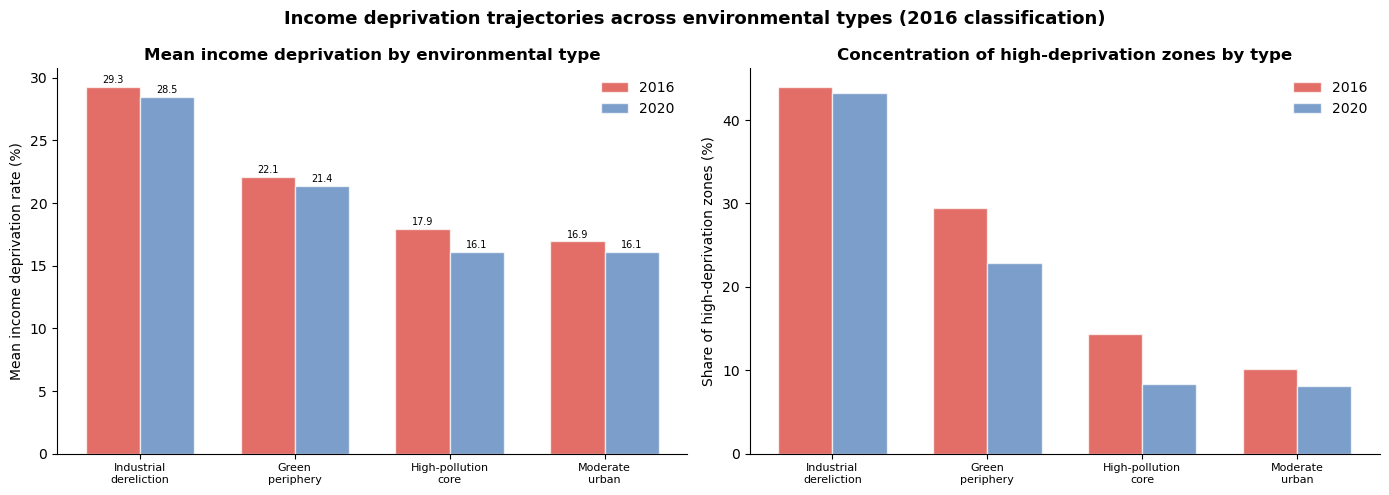

In [24]:
# Visualisation: Income change by 2016 environmental type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

types_sorted = income_by_type.sort_values('Inc_2016', ascending=False).index.tolist()

# Panel 1: Mean income 2016 vs 2020 (grouped bar)
x = np.arange(len(types_sorted))
width = 0.35
bars1 = axes[0].bar(x - width/2, [income_by_type.loc[t, 'Inc_2016'] for t in types_sorted],
                     width, label='2016', color='#d73027', alpha=0.7, edgecolor='white')
bars2 = axes[0].bar(x + width/2, [income_by_type.loc[t, 'Inc_2020'] for t in types_sorted],
                     width, label='2020', color='#4575b4', alpha=0.7, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels([t.replace(' ', '\n') for t in types_sorted], fontsize=8)
axes[0].set_ylabel('Mean income deprivation rate (%)')
axes[0].set_title('Mean income deprivation by environmental type')
axes[0].legend(frameon=False)
axes[0].spines[['top', 'right']].set_visible(False)

# Add value labels
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}', ha='center', fontsize=7)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}', ha='center', fontsize=7)

# Panel 2: Share of high-deprivation zones
share_2016 = [share_table[share_table['Environmental type']==t]['Share 2016 (%)'].values[0]
              for t in types_sorted]
share_2020 = [share_table[share_table['Environmental type']==t]['Share 2020 (%)'].values[0]
              for t in types_sorted]

bars3 = axes[1].bar(x - width/2, share_2016, width, label='2016',
                     color='#d73027', alpha=0.7, edgecolor='white')
bars4 = axes[1].bar(x + width/2, share_2020, width, label='2020',
                     color='#4575b4', alpha=0.7, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels([t.replace(' ', '\n') for t in types_sorted], fontsize=8)
axes[1].set_ylabel('Share of high-deprivation zones (%)')
axes[1].set_title('Concentration of high-deprivation zones by type')
axes[1].legend(frameon=False)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Income deprivation trajectories across environmental types (2016 classification)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_2016env_income_change.png', dpi=200, bbox_inches='tight')
plt.show()

In [25]:
# Statistical test: does income change differ across env types?
from scipy.stats import kruskal

groups = [gdf[gdf['EnvType_2016'] == t]['Inc_Change'].values
          for t in sorted(gdf['EnvType_2016'].unique())]
H, p = kruskal(*groups)
print(f'Kruskal-Wallis test (income change across 2016 env types): H={H:.2f}, p={p:.4f}')

if p < 0.05:
    print('→ Significant differences in income trajectories across environmental types.')
else:
    print('→ No significant differences. Income trajectories are similar across')
    print('  environmental types, consistent with the 2020 analysis.')

Kruskal-Wallis test (income change across 2016 env types): H=4.29, p=0.2316
→ No significant differences. Income trajectories are similar across
  environmental types, consistent with the 2020 analysis.


In [17]:
import subprocess
subprocess.run(['jupyter', 'nbconvert', '--to', 'html', 'Typological_Analysis_PlanC.ipynb'])

CompletedProcess(args=['jupyter', 'nbconvert', '--to', 'html', 'Typological_Analysis_PlanC.ipynb'], returncode=0)